In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display

import gc
import itertools

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [2]:
# NSigmaTPC:
sigma_limit = 3
cut1 = (
    "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
    "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
)

# NsigmaTOF:
sigma_limit = 3
cut2 = (
    "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
    "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
    "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
)

# DCA_XY:
cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# FINAL CUT EXPRESSION:
cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

In [3]:
final_results = pd.read_pickle("BKG_1_30.pkl")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:.2f} MB")
final_results

It occupies 663.70 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,2,5.357436e-06,1.225685,3.566073,0.331722,0.009042,-0.956933,2.820192,-0.858816,11.830413,-0.001041,0.822375,12.974496,86.617554,-0.005145,-2.222589,14.827864,10.183949,42.177925
1,2,5.610771e-06,0.816327,1.787505,-0.057076,0.073930,0.996259,0.965800,-1.453411,-14.772752,-0.001091,0.822375,12.974496,86.617554,-0.005145,-0.958469,3.312149,10.183949,42.177925
2,2,1.302406e-05,1.648999,1.639863,-0.623896,0.019964,-0.193247,1.407254,2.516854,-7.063940,-0.002532,0.822375,12.974496,86.617554,-0.005145,1.150332,2.576092,10.183949,42.177925
3,2,-6.124314e-05,1.101948,1.320438,0.177381,0.050782,-0.621115,0.573957,15.066970,49.151630,0.011905,0.822375,12.974496,86.617554,-0.005145,25.062372,139.430527,10.183949,42.177925
4,2,-2.687807e-05,1.530230,0.380101,-0.180018,0.012975,-0.633466,0.521550,-5.743346,-35.371128,0.005225,0.822375,12.974496,86.617554,-0.005145,-0.804597,0.279523,10.183949,42.177925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4578562,986432,1.342664e-06,1.248318,0.868656,-0.206863,0.020731,-0.188663,0.826627,-1.751481,-23.580986,0.000920,0.494894,11.349110,48.025417,0.001460,-0.646658,-3.551281,0.402253,-1.259232
4578563,986432,5.669573e-06,0.938762,0.584767,0.150662,0.025910,0.338123,0.323290,-9.923779,-999.000000,0.003883,0.494894,11.349110,48.025417,0.001460,-0.031754,-999.000000,0.402253,-1.259232
4578564,986433,8.395454e-07,3.030819,1.319280,2.210707,0.011254,-0.191441,2.161108,0.324399,20.150930,0.000169,1.076981,-1.107388,22.093863,0.004982,-1.240577,24.967270,-0.262186,6.665131
4578565,986433,-1.763569e-05,3.198169,1.482737,1.952179,0.007573,0.158796,2.368999,1.026240,-999.000000,-0.003540,1.076981,-1.107388,22.093863,0.004982,-1.161817,-999.000000,-0.262186,6.665131


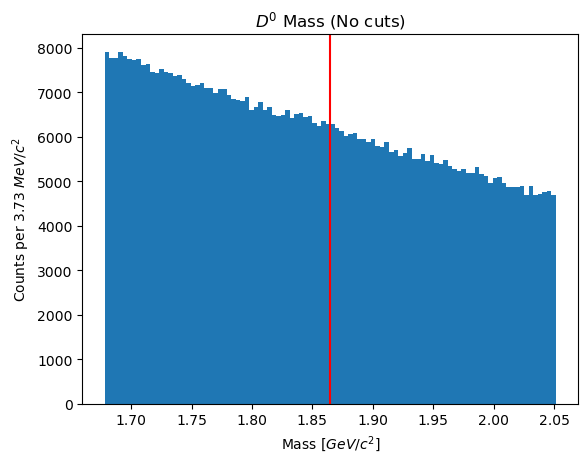

In [4]:
# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
plt.hist(final_results["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass (No cuts)")
#plt.savefig("D0_Mass_MC.png")
plt.show()

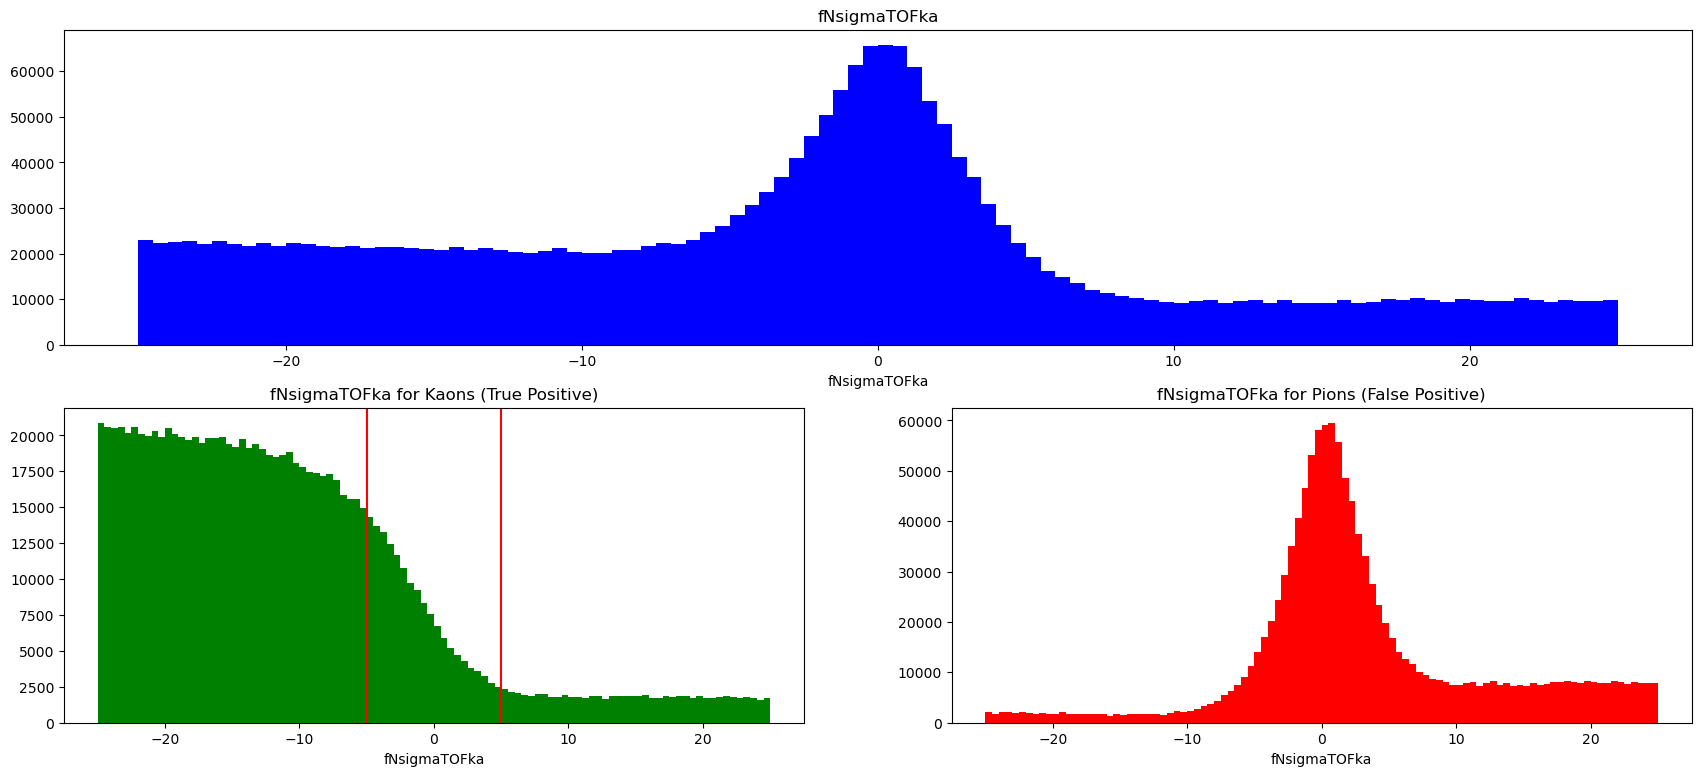

In [5]:
mosaic = [
    ["top", "top"],
    ["left", "right"]
]

fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TOF, MAX_TOF = -25, 25
axes["top"].hist(np.concat([final_results["KA_TOFka"],final_results["PI_TOFka"]]), bins=N_BINS, color="blue", range=(MIN_TOF, MAX_TOF))
axes["top"].set_title("fNsigmaTOFka")
axes["top"].set_xlabel("fNsigmaTOFka")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TOFka"], bins=N_BINS, color="green", range=(MIN_TOF, MAX_TOF))
axes["left"].set_title("fNsigmaTOFka for Kaons (True Positive)")
axes["left"].set_xlabel("fNsigmaTOFka")
axes["left"].set_label("Counts")
axes["left"].axvline(x=-5, color="red")
axes["left"].axvline(x=+5, color="red")

axes["right"].hist(final_results["PI_TOFka"], bins=N_BINS, color="red", range=(MIN_TOF, MAX_TOF))
axes["right"].set_title("fNsigmaTOFka for Pions (False Positive)")
axes["right"].set_xlabel("fNsigmaTOFka")
axes["right"].set_label("Counts")

plt.show()

---KA only---
True Positive data remaining for -3 < TOF_KA < 3:     1.92%   (4490648 rows eliminated.)
True Positive data remaining for -3 < TOF_KA < 3 or unavailable:     60.65%   (1801603 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TOF_KA < 3:     5.85%   (4310911 rows eliminated.)
True&False Positive data remaining for -3 < TOF_KA < 3 or unavailable:     88.46%   (528305 rows eliminated.)


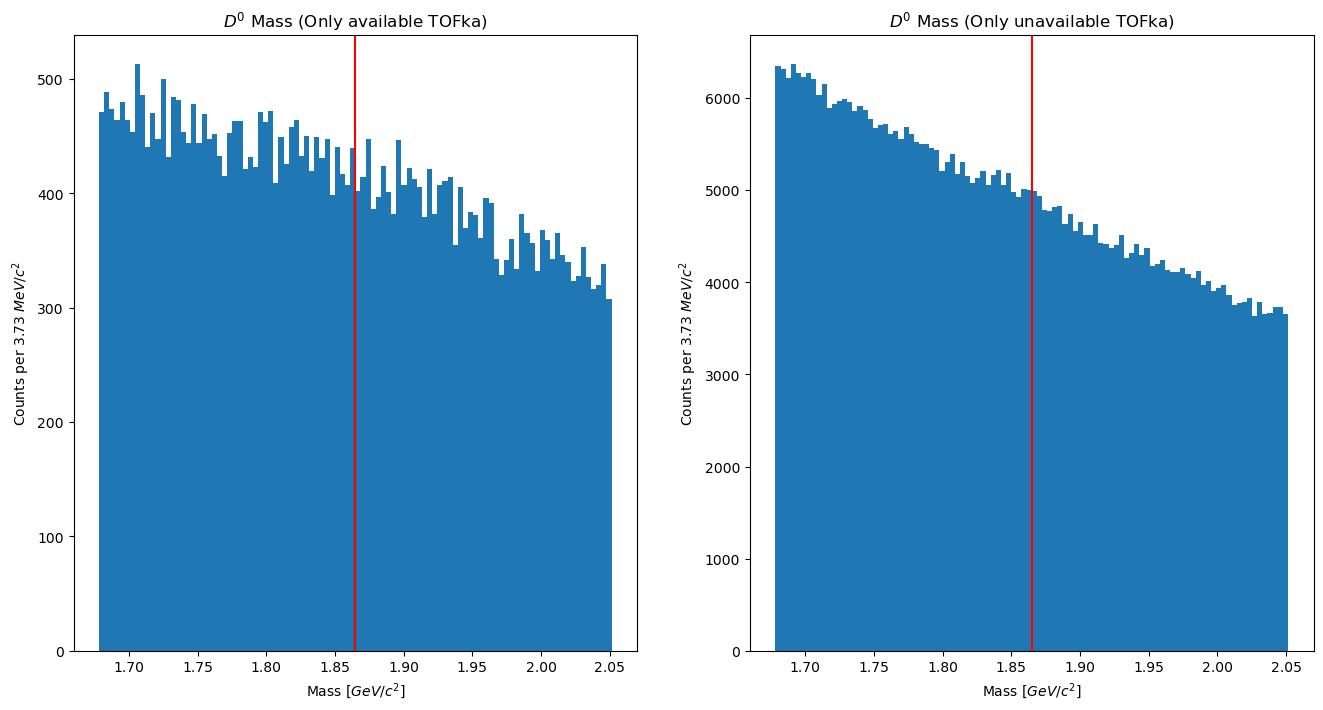

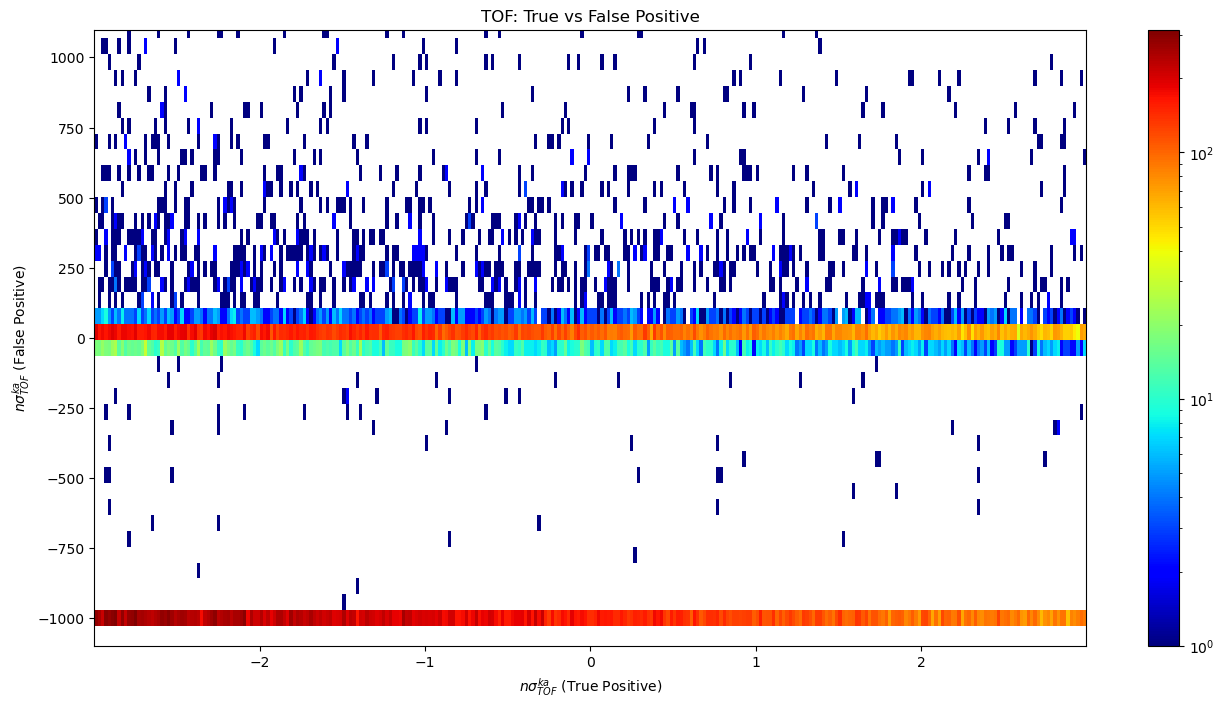

Fraction of True Positive Kaons with corresponding unavailable TOF in case of particle switch: 0.010826749941630208


In [6]:
# in cut2:
# "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
# "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) |

min_cut_TOF_KA, max_cut_TOF_KA = -3, 3
NA_TOF_KA = 998.5
start_size = len(final_results)
middle_size = sum(final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))
final_size = middle_size + sum(final_results["KA_TOFka"].abs() > NA_TOF_KA )
print("---KA only---")
print(f"True Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
middle_size = sum( ( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["PI_TOFka"].abs() < NA_TOF_KA) ) |
                   ( final_results["PI_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["KA_TOFka"].abs()< NA_TOF_KA) ) )
final_size = middle_size + sum( ( final_results["KA_TOFka"].abs() > NA_TOF_KA ) | ( final_results["PI_TOFka"].abs() > NA_TOF_KA ) )
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Are rows corresponding to unavailable TOFka important? How does the invariant mass look without them?
only_available_TOF = final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["PI_TOFka"].abs() < NA_TOF_KA) ) |
                   ( final_results["PI_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["KA_TOFka"].abs()< NA_TOF_KA) )]

MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
fig, ax  = plt.subplots(1, 2, figsize=(16,8))
ax[0].hist(only_available_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0].axvline(x=m_d0, color="red")
ax[0].set_xlabel("Mass [$GeV/c^2$]")
ax[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0].set_title("$D^0$ Mass (Only available TOFka)")

# only UNAVAILABLE
only_unavailable_TOF = final_results[( final_results["KA_TOFka"].abs() > NA_TOF_KA ) | ( final_results["PI_TOFka"].abs() > NA_TOF_KA ) ]
ax[1].hist(only_unavailable_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[1].axvline(x=m_d0, color="red")
ax[1].set_xlabel("Mass [$GeV/c^2$]")
ax[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[1].set_title("$D^0$ Mass (Only unavailable TOFka)")

plt.show()

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,8))
plt.hist2d(final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))]["KA_TOFka"],
           final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))]["PI_TOFka"],
           (300, 300), cmap="jet", norm=LogNorm() )
plt.colorbar()
plt.xlabel(r"$n\sigma^{ka}_{TOF}$ (True Positive)")
plt.ylabel(r"$n\sigma^{ka}_{TOF}$ (False Positive)")
plt.ylim(-1.1*NA_TOF_KA, 1.1*NA_TOF_KA )
plt.title("TOF: True vs False Positive")
plt.show()

print("Fraction of True Positive Kaons with corresponding unavailable TOF in case of particle switch:",
      sum( (final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)) & ( (final_results["PI_TOFka"].abs() > NA_TOF_KA) ) )/len(final_results) )

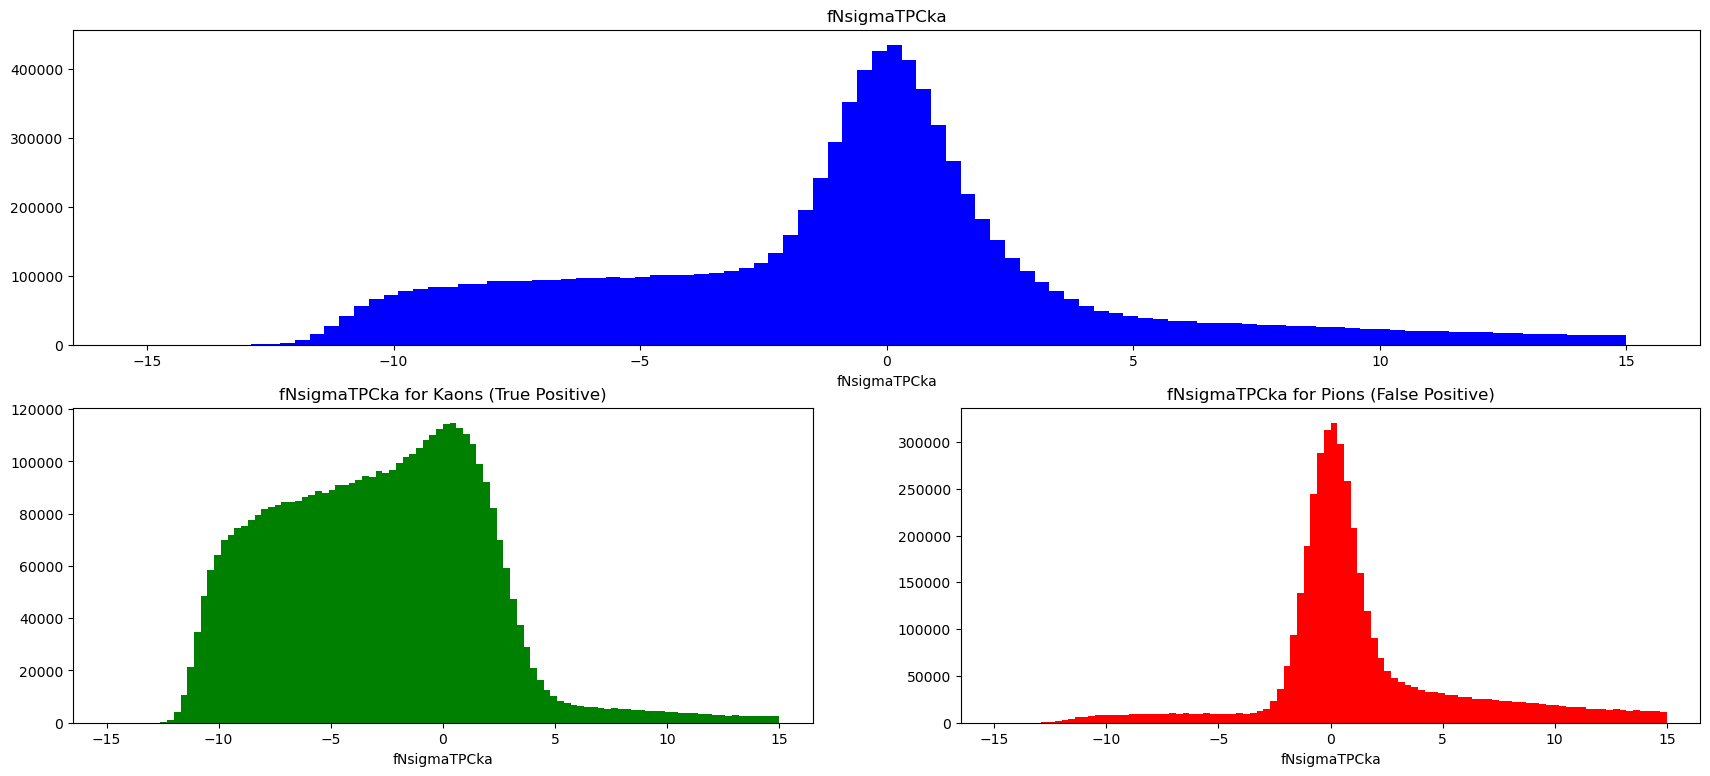

In [7]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TPC, MAX_TPC = -15, +15
axes["top"].hist(np.concat([final_results["KA_TPCka"],final_results["PI_TPCka"]]), bins=N_BINS, color="blue", range=(MIN_TPC, MAX_TPC))
axes["top"].set_title("fNsigmaTPCka")
axes["top"].set_xlabel("fNsigmaTPCka")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TPCka"], bins=N_BINS, color="green", range=(MIN_TPC, MAX_TPC))
axes["left"].set_title("fNsigmaTPCka for Kaons (True Positive)")
axes["left"].set_xlabel("fNsigmaTPCka")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["PI_TPCka"], bins=N_BINS, color="red", range=(MIN_TPC, MAX_TPC))
axes["right"].set_title("fNsigmaTPCka for Pions (False Positive)")
axes["right"].set_xlabel("fNsigmaTPCka")
axes["right"].set_label("Counts")

plt.show()

---KA only---
True Positive data remaining for -3 < TPC_KA < 3:     43.47%   (2588251 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TPC_KA < 3:     80.57%   (889674 rows eliminated.)


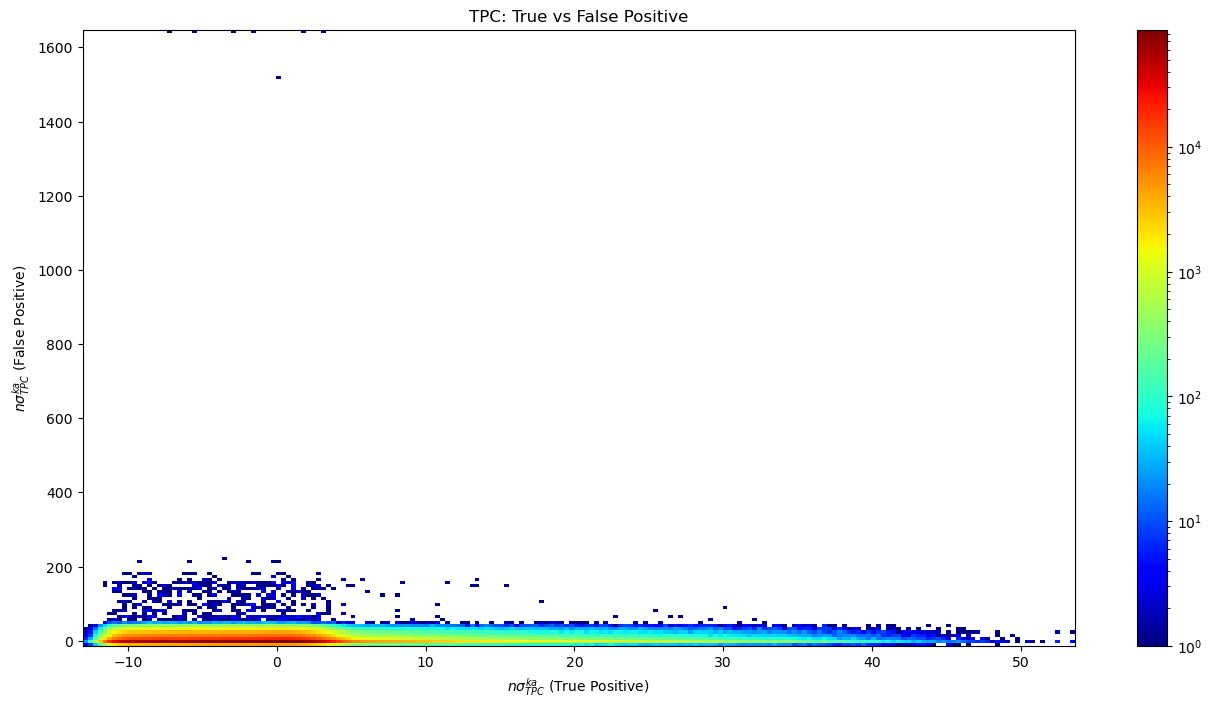

In [8]:
# in cut1:
# "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
# "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"

min_cut_TPC_KA, max_cut_TPC_KA = -3, 3
start_size = len(final_results)
final_size = sum(final_results["KA_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA))
print("---KA only---")
print(f"True Positive data remaining for {min_cut_TPC_KA} < TPC_KA < {max_cut_TPC_KA}:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
final_size = sum( ( final_results["KA_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA) ) |
                   ( final_results["PI_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA)  ) )
print(f"True&False Positive data remaining for {min_cut_TPC_KA} < TPC_KA < {max_cut_TPC_KA}:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,8))
plt.hist2d(final_results["KA_TPCka"], final_results["PI_TPCka"], (200, 200), cmap="jet", norm=LogNorm() )
plt.colorbar()
plt.xlabel(r"$n\sigma^{ka}_{TPC}$ (True Positive)")
plt.ylabel(r"$n\sigma^{ka}_{TPC}$ (False Positive)")
plt.title("TPC: True vs False Positive")
plt.show()

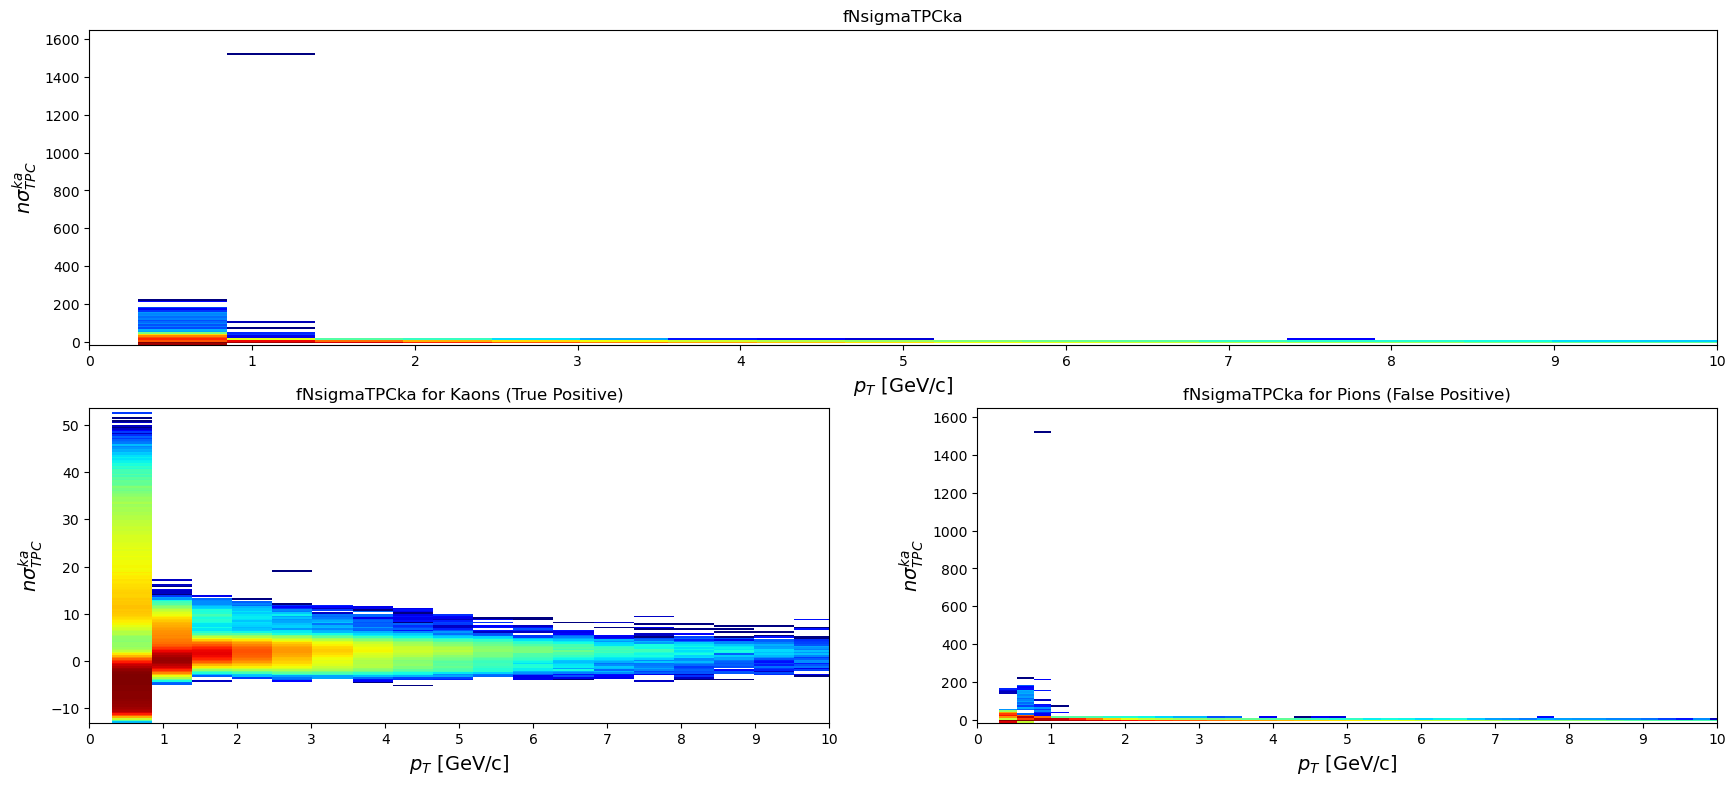

In [9]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TPCka"], final_results["PI_TPCka"]]), (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTPCka")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TPCka"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTPCka for Kaons (True Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TPCka"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTPCka for Pions (False Positive)")

plt.show()

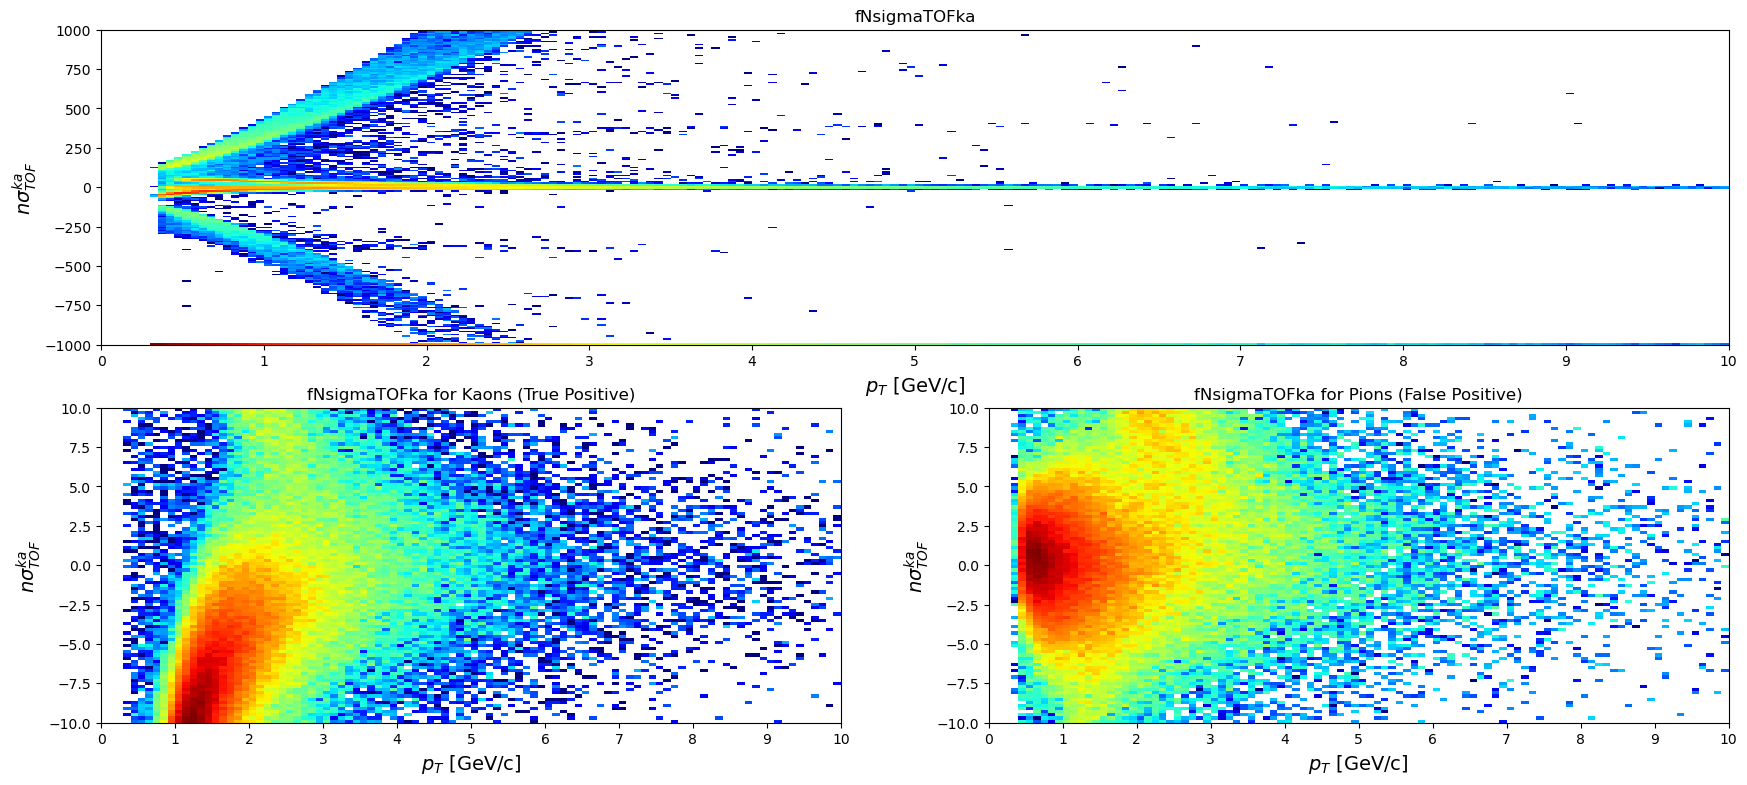

In [10]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
TOF_lower, TOF_upper = -1000, +1000
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TOFka"], final_results["PI_TOFka"]]), (200, 200), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[TOF_lower,TOF_upper]]))
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTOFka")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TOFka"], (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTOFka for Kaons (True Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TOFka"], (100, 100), cmap="jet", norm=LogNorm(),
                     range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTOFka for Pions (False Positive)")

plt.show()

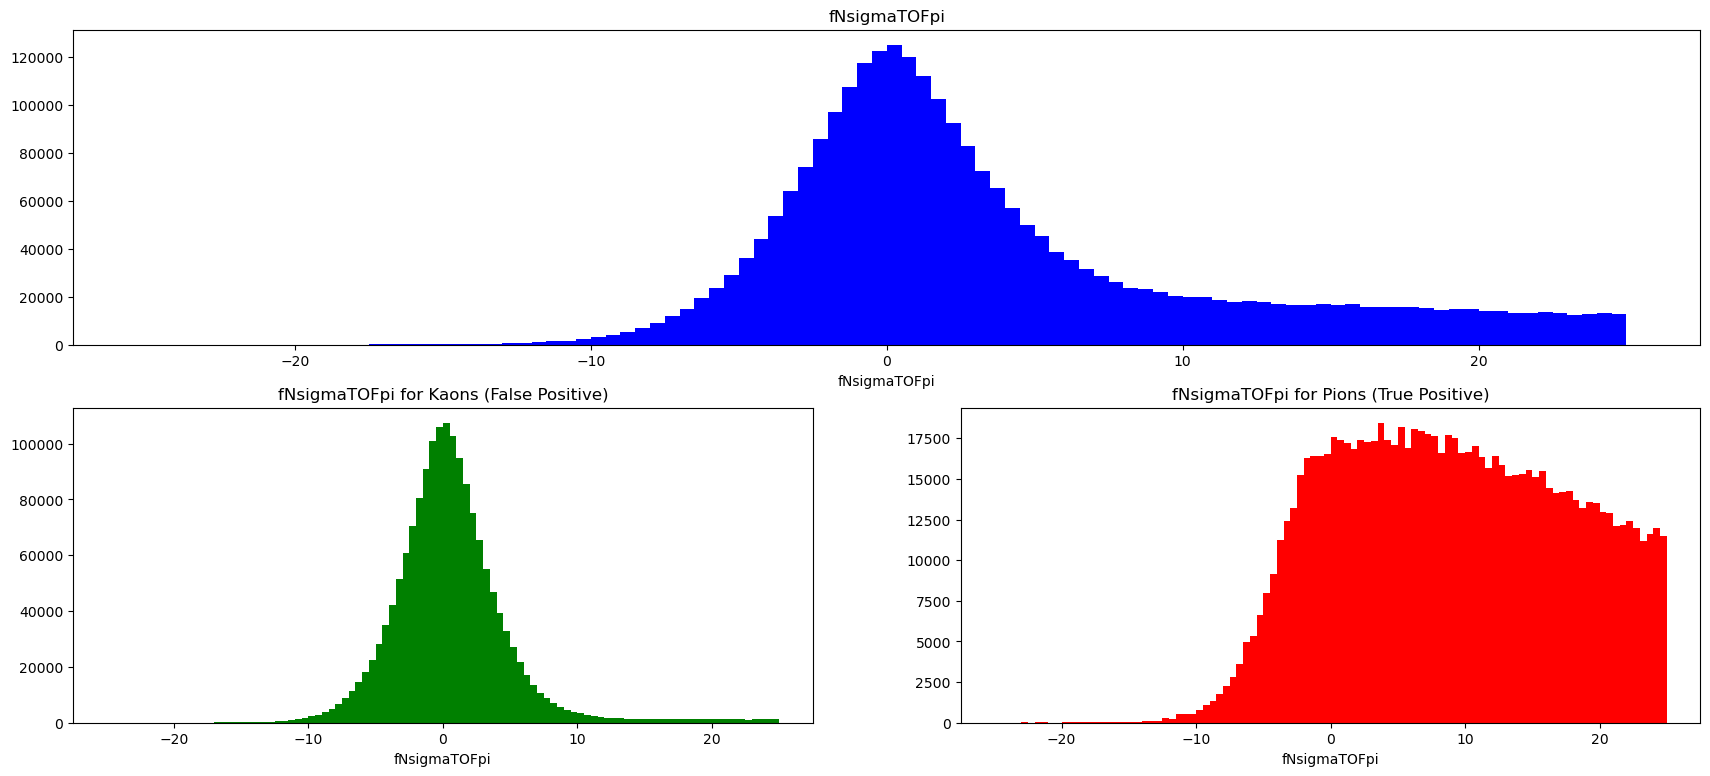

In [11]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TOF, MAX_TOF = -25, 25
axes["top"].hist(np.concat([final_results["KA_TOFpi"],final_results["PI_TOFpi"]]), bins=N_BINS, color="blue", range=(MIN_TOF, MAX_TOF))
axes["top"].set_title("fNsigmaTOFpi")
axes["top"].set_xlabel("fNsigmaTOFpi")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TOFpi"], bins=N_BINS, color="green", range=(MIN_TOF, MAX_TOF))
axes["left"].set_title("fNsigmaTOFpi for Kaons (False Positive)")
axes["left"].set_xlabel("fNsigmaTOFpi")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["PI_TOFpi"], bins=N_BINS, color="red", range=(MIN_TOF, MAX_TOF))
axes["right"].set_title("fNsigmaTOFpi for Pions (True Positive)")
axes["right"].set_xlabel("fNsigmaTOFpi")
axes["right"].set_label("Counts")

plt.show()

---Pion only---
True Positive data remaining for -3 < TOF_PI < 3:     4.32%   (4380710 rows eliminated.)
True Positive data remaining for -3 < TOF_PI < 3 or unavailable:     65.88%   (1562114 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TOF_PI < 3:     9.95%   (4122862 rows eliminated.)
True&False Positive data remaining for -3 < TOF_PI < 3 or unavailable:     94.10%   (270078 rows eliminated.)


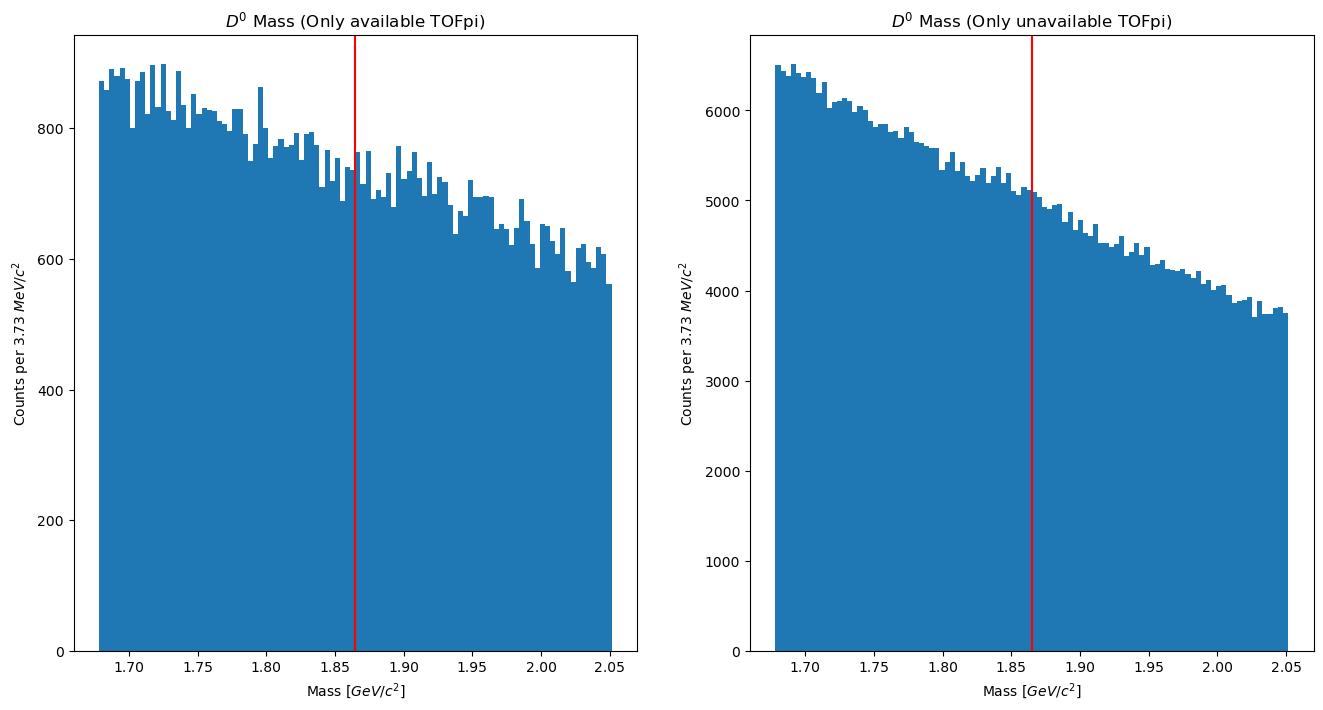

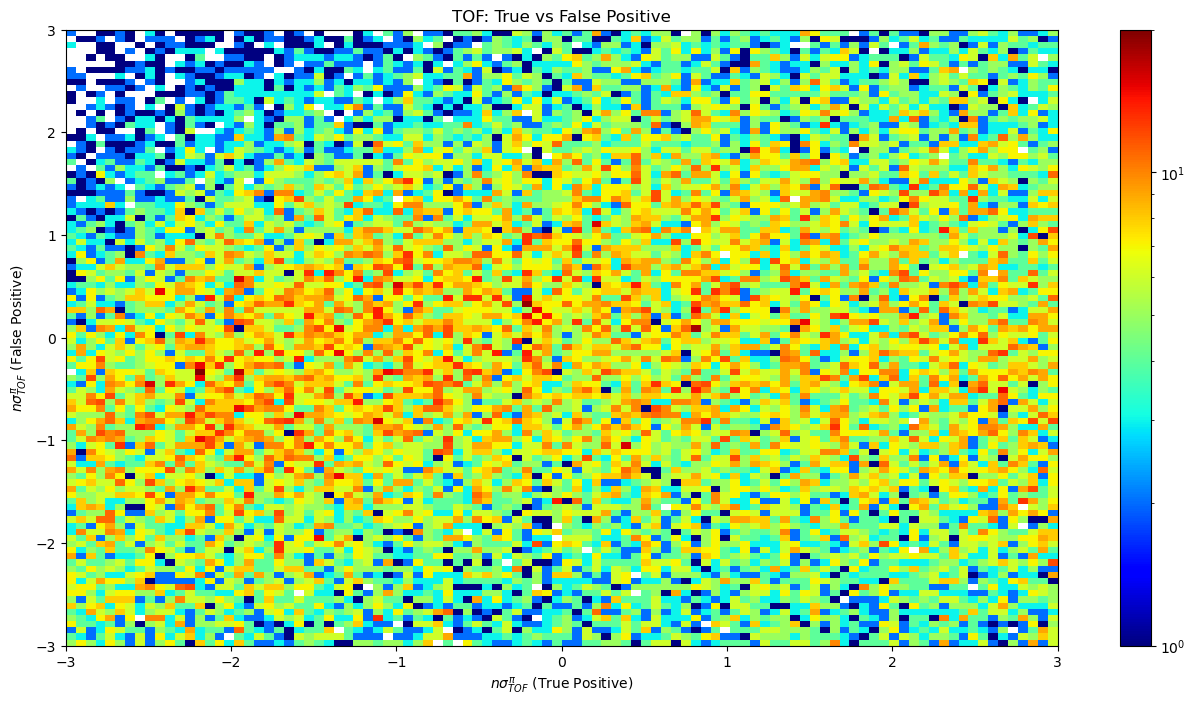

Fraction of True Positive Pions with corresponding unavailable TOF in case of particle switch: 0.025225359812360505


In [12]:
# in cut2:
# "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
# "(fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "

min_cut_TOF_PI, max_cut_TOF_PI = -3, 3
NA_TOF_PI = 998.5
start_size = len(final_results)
middle_size = sum(final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))
final_size = middle_size + sum(final_results["PI_TOFpi"].abs() > NA_TOF_PI )
print("---Pion only---")
print(f"True Positive data remaining for {min_cut_TOF_PI} < TOF_PI < {max_cut_TOF_PI}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True Positive data remaining for {min_cut_TOF_PI} < TOF_PI < {max_cut_TOF_PI} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
middle_size = sum( ( final_results["KA_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["PI_TOFpi"].abs() < NA_TOF_PI) ) |
                   ( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["KA_TOFpi"].abs()< NA_TOF_PI) ) )
final_size = middle_size + sum( ( final_results["KA_TOFpi"].abs() > NA_TOF_PI ) | ( final_results["PI_TOFpi"].abs() > NA_TOF_PI ) )
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_PI < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_PI < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Are rows corresponding to unavailable TOFpi important? How does the invariant mass look without them?
only_available_TOF = final_results[( final_results["KA_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["PI_TOFpi"].abs() < NA_TOF_PI) ) |
                   ( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["KA_TOFpi"].abs()< NA_TOF_PI) )]

MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
fig, ax  = plt.subplots(1, 2, figsize=(16,8))
ax[0].hist(only_available_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0].axvline(x=m_d0, color="red")
ax[0].set_xlabel("Mass [$GeV/c^2$]")
ax[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0].set_title("$D^0$ Mass (Only available TOFpi)")

# only UNAVAILABLE
only_unavailable_TOF = final_results[( final_results["KA_TOFpi"].abs() > NA_TOF_PI ) | ( final_results["PI_TOFpi"].abs() > NA_TOF_PI ) ]
ax[1].hist(only_unavailable_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[1].axvline(x=m_d0, color="red")
ax[1].set_xlabel("Mass [$GeV/c^2$]")
ax[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[1].set_title("$D^0$ Mass (Only unavailable TOFpi)")

plt.show()

test = final_results[final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)]
test = test[test["KA_TOFpi"].between(-10,10)]

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,8))
# plt.hist2d(final_results[( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))]["PI_TOFpi"],
#            final_results[( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))]["KA_TOFpi"],
#            (400, 400), cmap="jet", norm=LogNorm() )
plt.hist2d(test["PI_TOFpi"],
           test["KA_TOFpi"],
           (100, 100), cmap="jet", norm=LogNorm(), range=[[-3, 3], [-3, 3]] )

plt.colorbar()
plt.xlabel(r"$n\sigma^{\pi}_{TOF}$ (True Positive)")
plt.ylabel(r"$n\sigma^{\pi}_{TOF}$ (False Positive)")
#plt.ylim(-1.1*NA_TOF_PI, 1.1*NA_TOF_PI )
plt.title("TOF: True vs False Positive")
plt.show()

print("Fraction of True Positive Pions with corresponding unavailable TOF in case of particle switch:",
      sum( (final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)) & ( (final_results["KA_TOFpi"].abs() > NA_TOF_PI) ) )/len(final_results) )

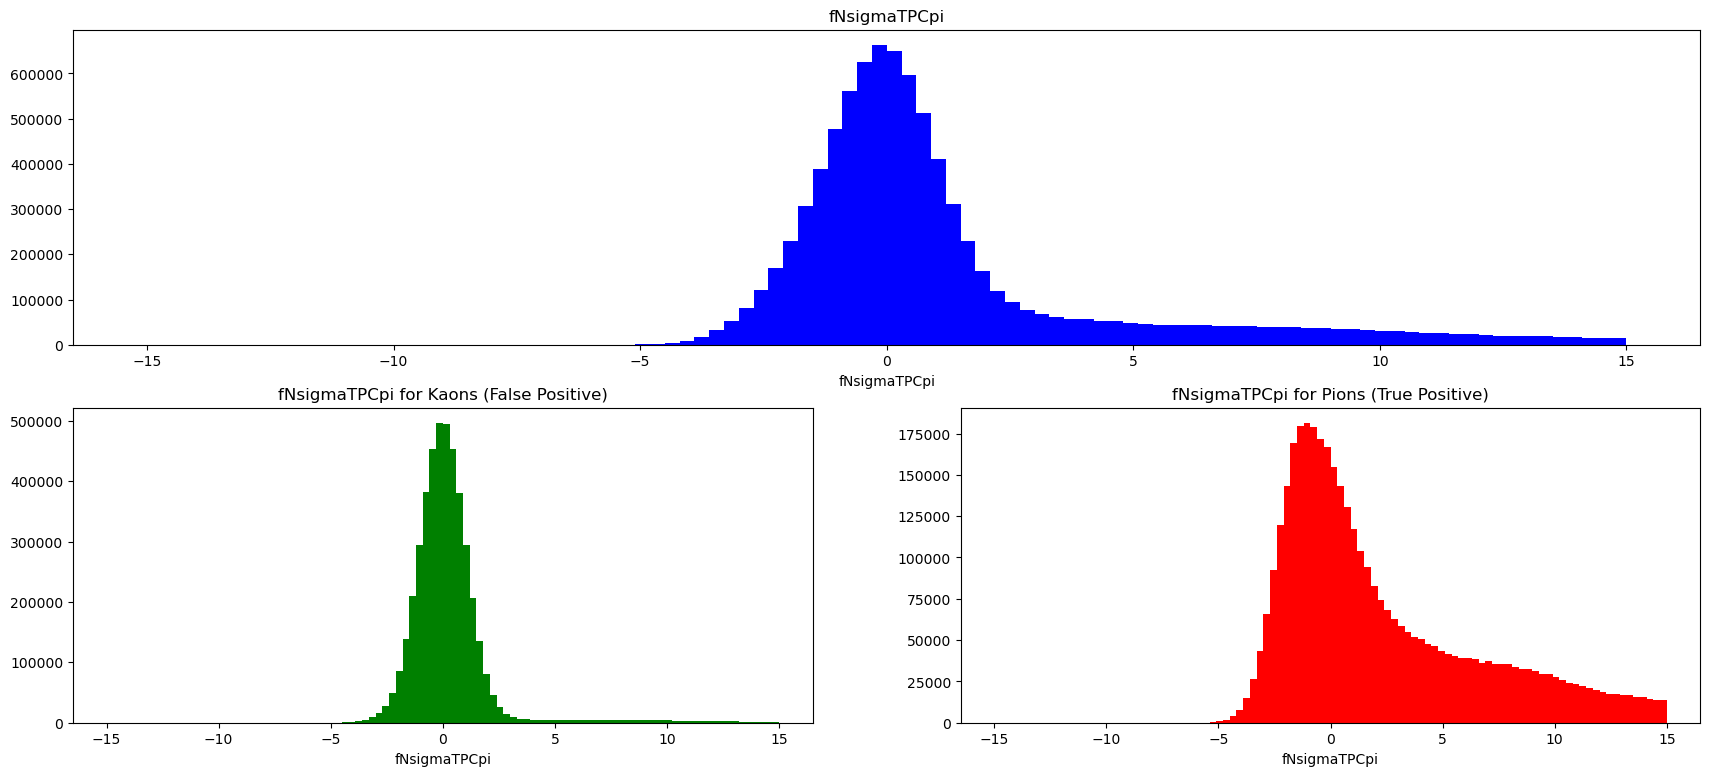

In [13]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TPC, MAX_TPC = -15, +15
axes["top"].hist(np.concat([final_results["KA_TPCpi"],final_results["PI_TPCpi"]]), bins=N_BINS, color="blue", range=(MIN_TPC, MAX_TPC))
axes["top"].set_title("fNsigmaTPCpi")
axes["top"].set_xlabel("fNsigmaTPCpi")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TPCpi"], bins=N_BINS, color="green", range=(MIN_TPC, MAX_TPC))
axes["left"].set_title("fNsigmaTPCpi for Kaons (False Positive)")
axes["left"].set_xlabel("fNsigmaTPCpi")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["PI_TPCpi"], bins=N_BINS, color="red", range=(MIN_TPC, MAX_TPC))
axes["right"].set_title("fNsigmaTPCpi for Pions (True Positive)")
axes["right"].set_xlabel("fNsigmaTPCpi")
axes["right"].set_label("Counts")

plt.show()

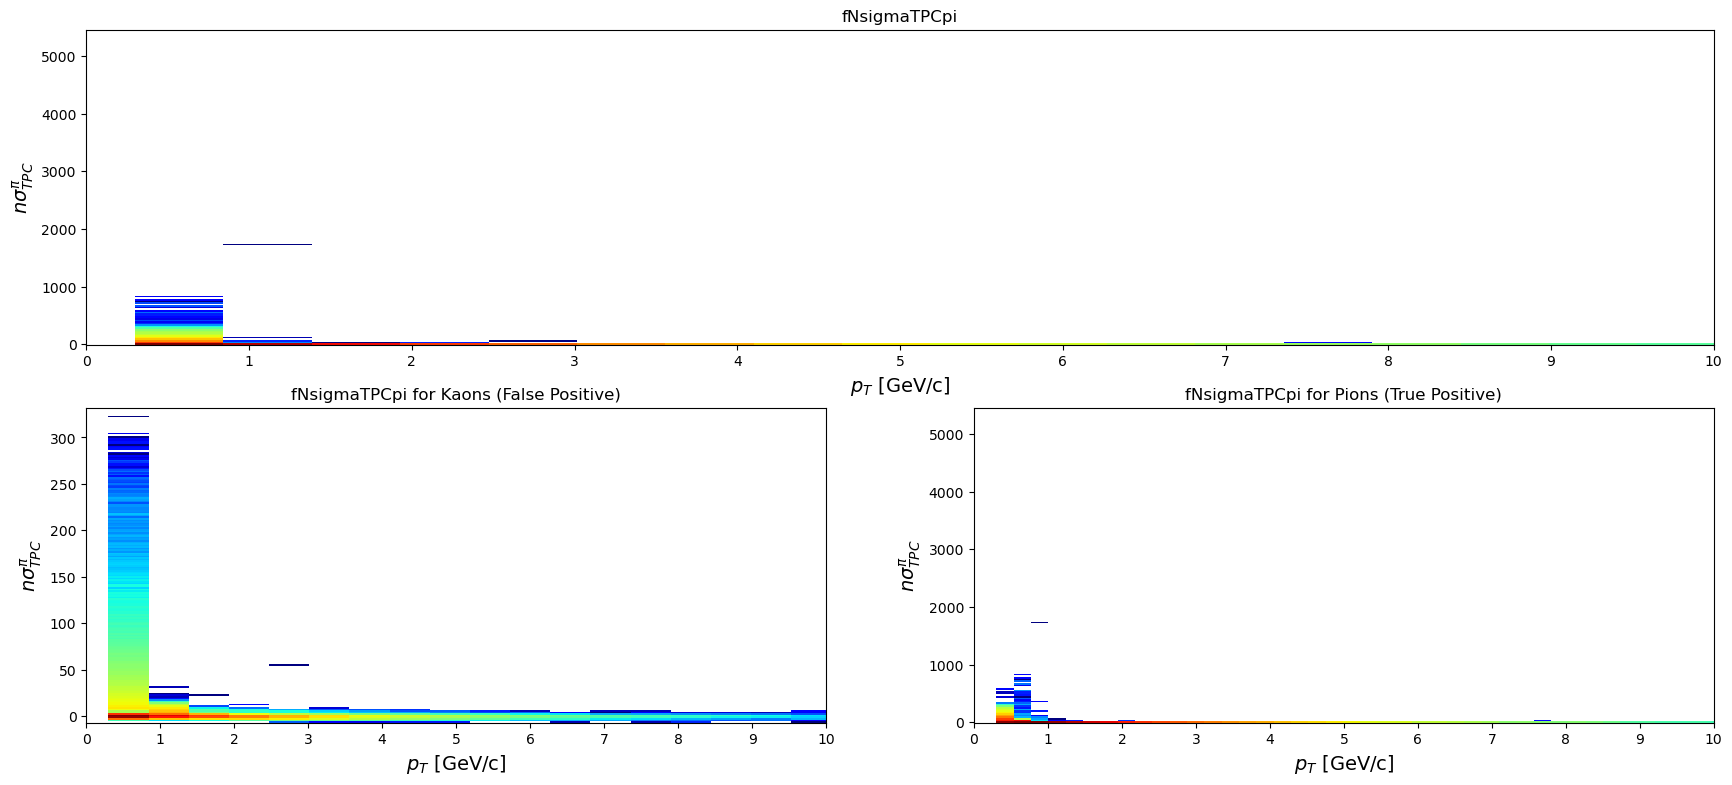

In [14]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TPCpi"], final_results["PI_TPCpi"]]), (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTPCpi")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TPCpi"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTPCpi for Kaons (False Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TPCpi"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTPCpi for Pions (True Positive)")

plt.show()

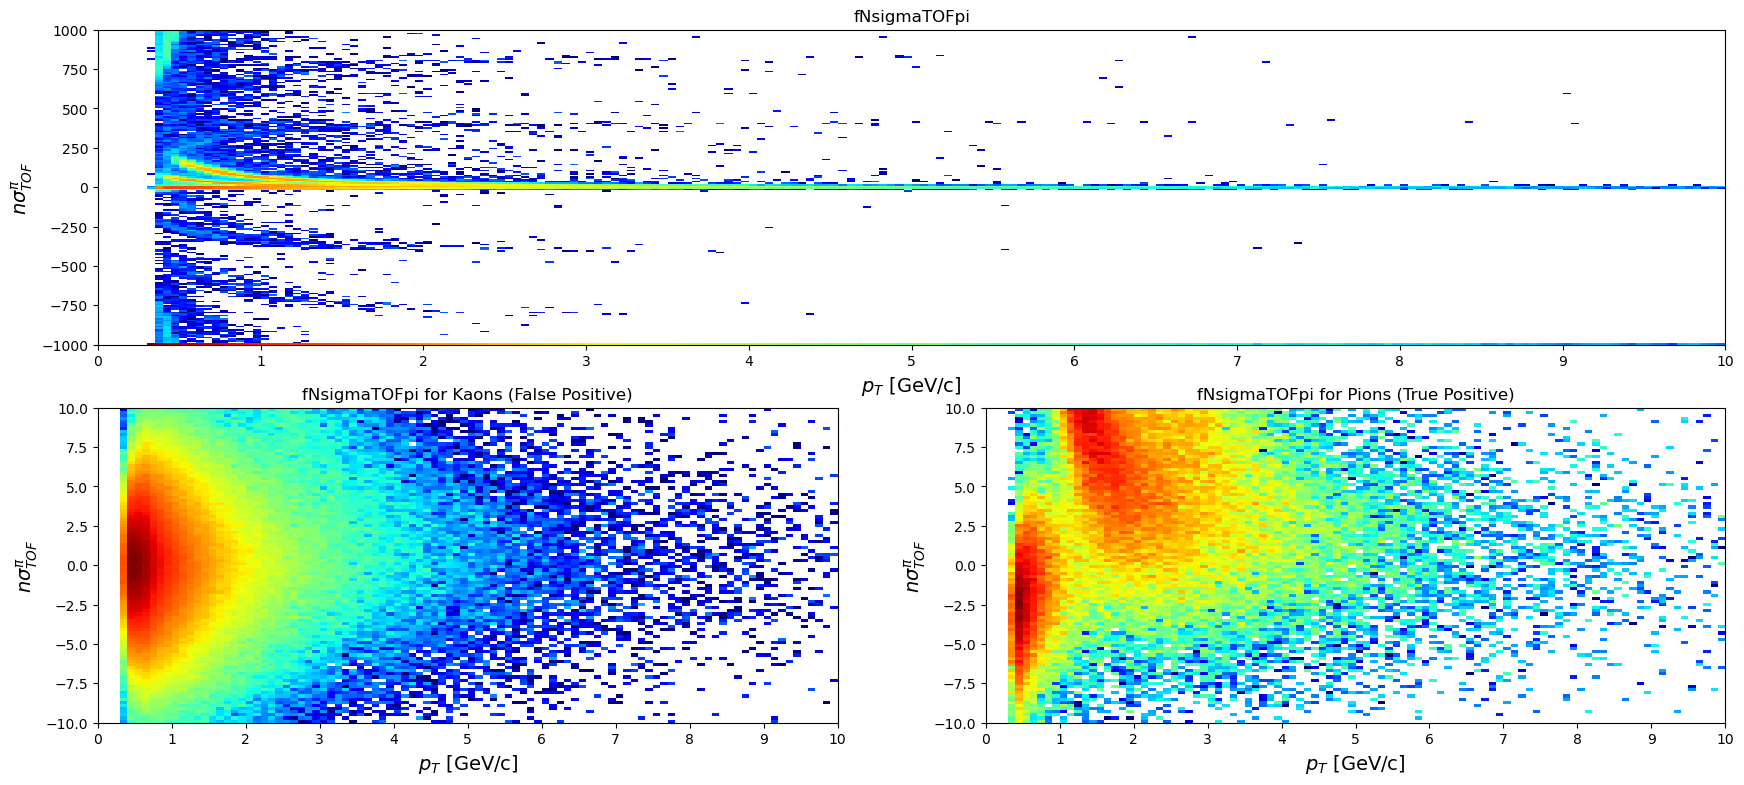

In [15]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
TOF_lower, TOF_upper = -1000, +1000
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TOFpi"], final_results["PI_TOFpi"]]), (200, 200), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[TOF_lower,TOF_upper]]))
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTOFpi")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TOFpi"], (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTOFpi for Kaons (False Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TOFpi"], (100, 100), cmap="jet", norm=LogNorm(),
                     range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTOFpi for Pions (True Positive)")

plt.show()

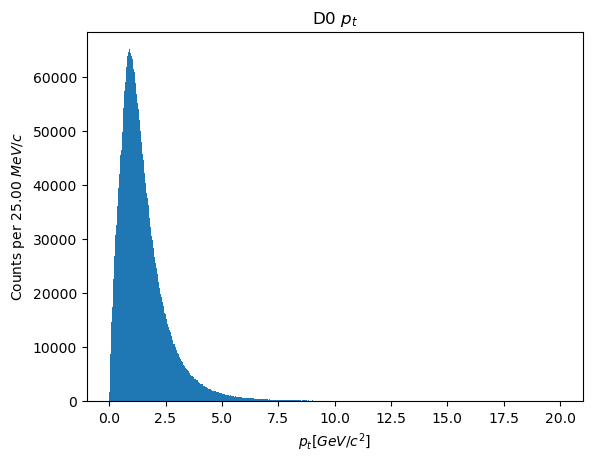

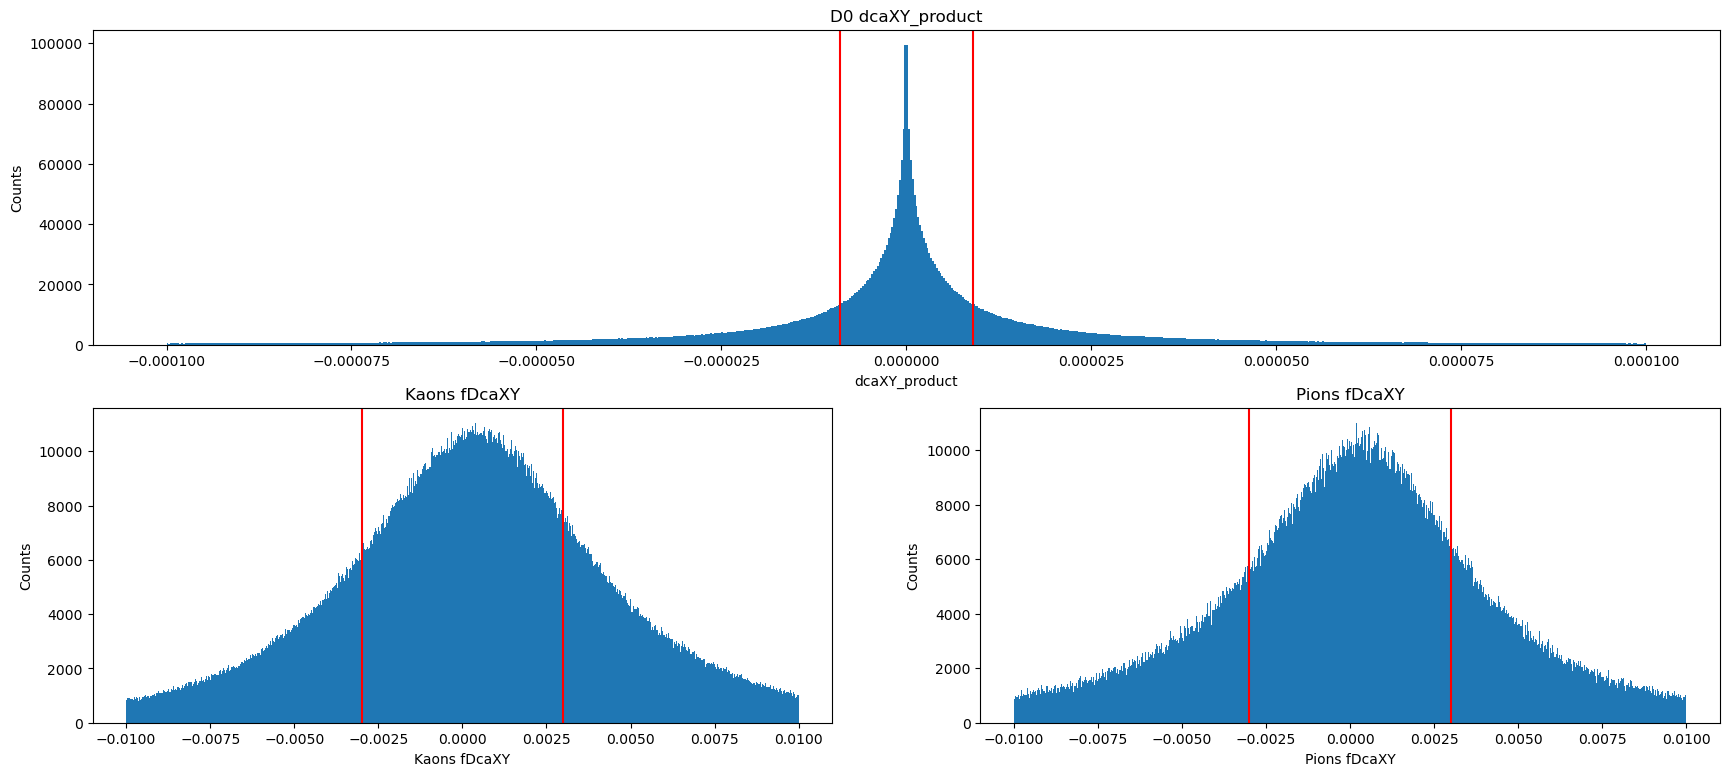

In [16]:
MIN_pt, MAX_pt = 0, 20
N_BINS = 800
plt.hist(final_results["pt"], range=(MIN_pt, MAX_pt), bins=N_BINS)
plt.xlabel("$p_t [GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_pt -  MIN_pt)/N_BINS)*1000:.2f} $MeV/c$")
plt.title("D0 $p_t$")
plt.show()

# MIN_DCAXY, MAX_DCAXY = np.quantile(final_results["dcaXY_product"], 0.01), np.quantile(final_results["dcaXY_product"], 0.99)
MIN_DCAXY, MAX_DCAXY = -1e-04, +1e-04
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist(final_results["dcaXY_product"], bins=N_BINS, range=(MIN_DCAXY, MAX_DCAXY))
axes["top"].set_xlabel("dcaXY_product")
axes["top"].set_ylabel(f"Counts")
axes["top"].set_title("D0 dcaXY_product")
axes["top"].axvline(x=-3e-03**2, color="red")
axes["top"].axvline(x=+3e-03**2, color="red")

axes["left"].hist(final_results["KA_fDcaXY"], bins=N_BINS, range=(-np.sqrt(-MIN_DCAXY),np.sqrt(MAX_DCAXY)))
axes["left"].set_xlabel("Kaons fDcaXY")
axes["left"].set_ylabel(f"Counts")
axes["left"].set_title("Kaons fDcaXY")
axes["left"].axvline(x=-3e-03, color="red")
axes["left"].axvline(x=+3e-03, color="red")

axes["right"].hist(final_results["PI_fDcaXY"], bins=N_BINS, range=(-np.sqrt(-MIN_DCAXY),np.sqrt(MAX_DCAXY)))
axes["right"].set_xlabel("Pions fDcaXY")
axes["right"].set_ylabel(f"Counts")
axes["right"].set_title("Pions fDcaXY")
axes["right"].axvline(x=-3e-03, color="red")
axes["right"].axvline(x=+3e-03, color="red")
plt.show()

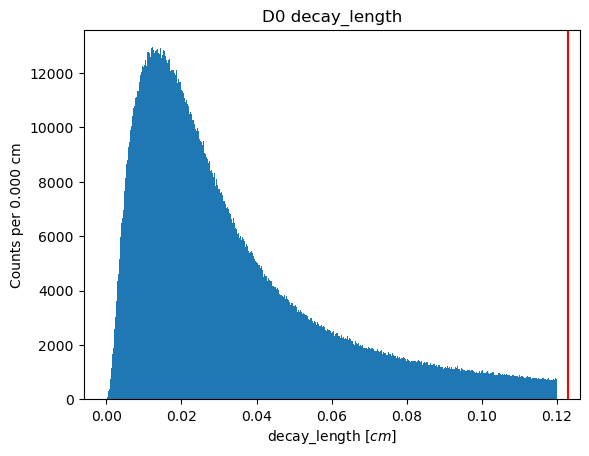

In [17]:
MIN_dl, MAX_dl = 0, 0.12
N_BINS = 800
plt.hist(final_results["decay_length"], bins=N_BINS, range=(MIN_dl, MAX_dl))
plt.xlabel("decay_length $[cm]$")
plt.ylabel(f"Counts per {((MAX_dl - MIN_dl)/N_BINS):.3f} cm")
plt.axvline(x=1.23*10e-02, color="red")
plt.title("D0 decay_length")
plt.show()

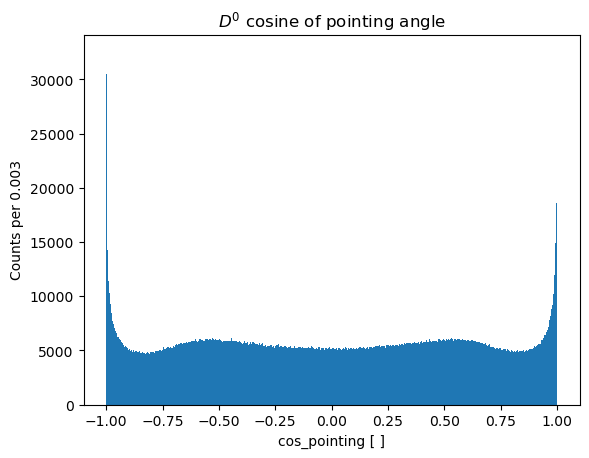

In [18]:
MIN_cos, MAX_cos = -1, 1
N_BINS = 800
plt.hist(final_results["cos_pointing"], bins=N_BINS, range=(MIN_cos, MAX_cos))
plt.xlabel("cos_pointing [ ]")
plt.ylabel(f"Counts per {((MAX_cos - MIN_cos)/N_BINS):.3f}")
plt.title("$D^0$ cosine of pointing angle")
plt.show()

In [21]:
# converting the cuts to work for this
# cut1 = (
#     "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
#     "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
# )

# # NsigmaTOF:
# sigma_limit = 3
# cut2 = (
#     "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
#     "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
#     "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
# )

# # DCA_XY:
# cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# # FINAL CUT EXPRESSION:
# cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

TOF_cut = 5
TPC_cut = 3
DCA_cut = 5e-03

cut1_A = final_results["PI_TPCpi"].between(-TPC_cut, +TPC_cut)
cut1_B = final_results["KA_TPCka"].between(-TPC_cut, +TPC_cut)
cut1_C = ( final_results["PI_pt"].between(0,1) ) & (final_results["KA_TPCka"].between(-15,0) )

cut1 = cut1_A | cut1_B | cut1_C

cut2_A = final_results["PI_TOFpi"].between(-TOF_cut, +TOF_cut)
cut2_B = final_results["KA_TOFka"].between(-TOF_cut, +TOF_cut)
cut2_C = ( np.isclose(final_results["PI_TOFpi"], -999.0) ) | ( np.isclose(final_results["KA_TOFka"], -999.0) )
cut2_D = ( final_results["PI_pt"].between(0,3) ) & (final_results["KA_TOFka"].between(-50,0) )

cut2 = cut2_A | cut2_B | cut2_C | cut2_D

cut3 = ( final_results["KA_fDcaXY"].abs() <= DCA_cut ) & ( final_results["PI_fDcaXY"].abs() <= DCA_cut )

final_cut = cut1 & cut2 & cut3

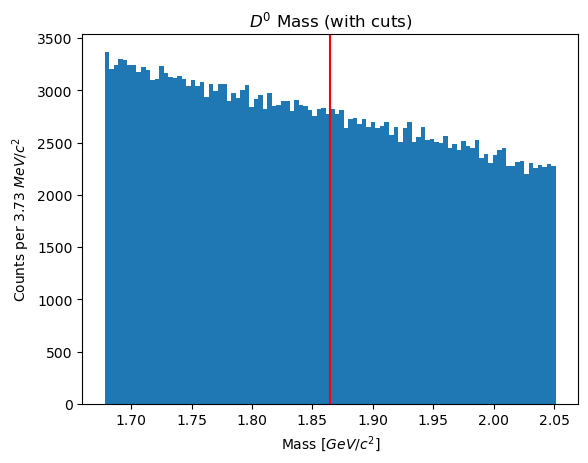

Amount of remaining data after cuts: 39.28%


,1A,1B,1C,2A,2B,2C,2D,TOT_1,TOT_2,TOT_3,FINAL
0,0.546278,0.434703,0.399014,0.067462,0.033571,0.824004,0.321503,0.927658,0.97137,0.431345,0.392809


In [22]:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
plt.hist(final_results[final_cut]["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass (with cuts)")
#plt.savefig("D0_Mass_MC.png")
plt.show()
print(f"Amount of remaining data after cuts: {sum(final_cut)/len(final_results)*100:.2f}%")

cut_effect = pd.DataFrame({
    "1A": sum(cut1_A)/len(final_results),
    "1B": sum(cut1_B)/len(final_results),
    "1C": sum(cut1_C)/len(final_results),
    "2A": sum(cut2_A)/len(final_results),
    "2B": sum(cut2_B)/len(final_results),
    "2C": sum(cut2_C)/len(final_results),
    "2D": sum(cut2_D)/len(final_results),
    "TOT_1": sum(cut1)/len(final_results),
    "TOT_2": sum(cut2)/len(final_results),
    "TOT_3":  sum(cut3)/len(final_results),
    "FINAL": sum(final_cut)/len(final_results)
}, index=[0])
display(cut_effect)